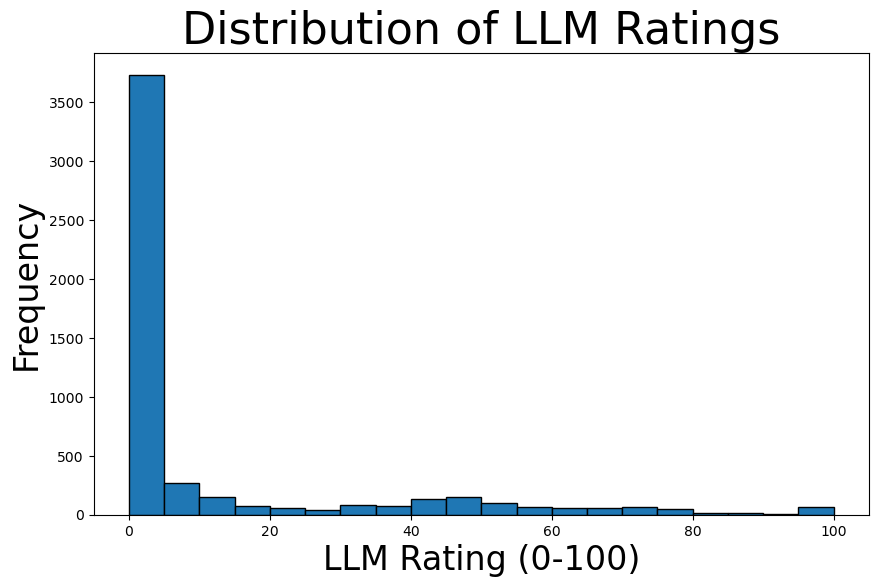

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the CSV file
df = pd.read_csv("../data/tmdb_movies_with_llm_rating.csv")

# Visualize the 'llm rating' column with a histogram
plt.figure(figsize=(10, 6))
plt.hist(df["overview_rating"], bins=20, edgecolor="black")
plt.title("Distribution of LLM Ratings", fontsize=32)
plt.xlabel("LLM Rating (0-100)", fontsize=24)
plt.ylabel("Frequency", fontsize=24)
plt.savefig("../results/llm_rating_histogram.png")  # Save the figure as a PNG file
plt.show()

                      roi  vote_average  overview_rating
roi              1.000000      0.277111         0.259026
vote_average     0.277111      1.000000         0.215977
overview_rating  0.259026      0.215977         1.000000
                      roi  overview_rating    budget   runtime      year  \
roi              1.000000         0.259026  0.050917  0.052458  0.039885   
overview_rating  0.259026         1.000000  0.372303  0.155588  0.007602   
budget           0.050917         0.372303  1.000000  0.380864  0.092263   
runtime          0.052458         0.155588  0.380864  1.000000  0.118242   
year             0.039885         0.007602  0.092263  0.118242  1.000000   
month           -0.017236         0.017915  0.028314  0.120624  0.003054   

                    month  
roi             -0.017236  
overview_rating  0.017915  
budget           0.028314  
runtime          0.120624  
year             0.003054  
month            1.000000  


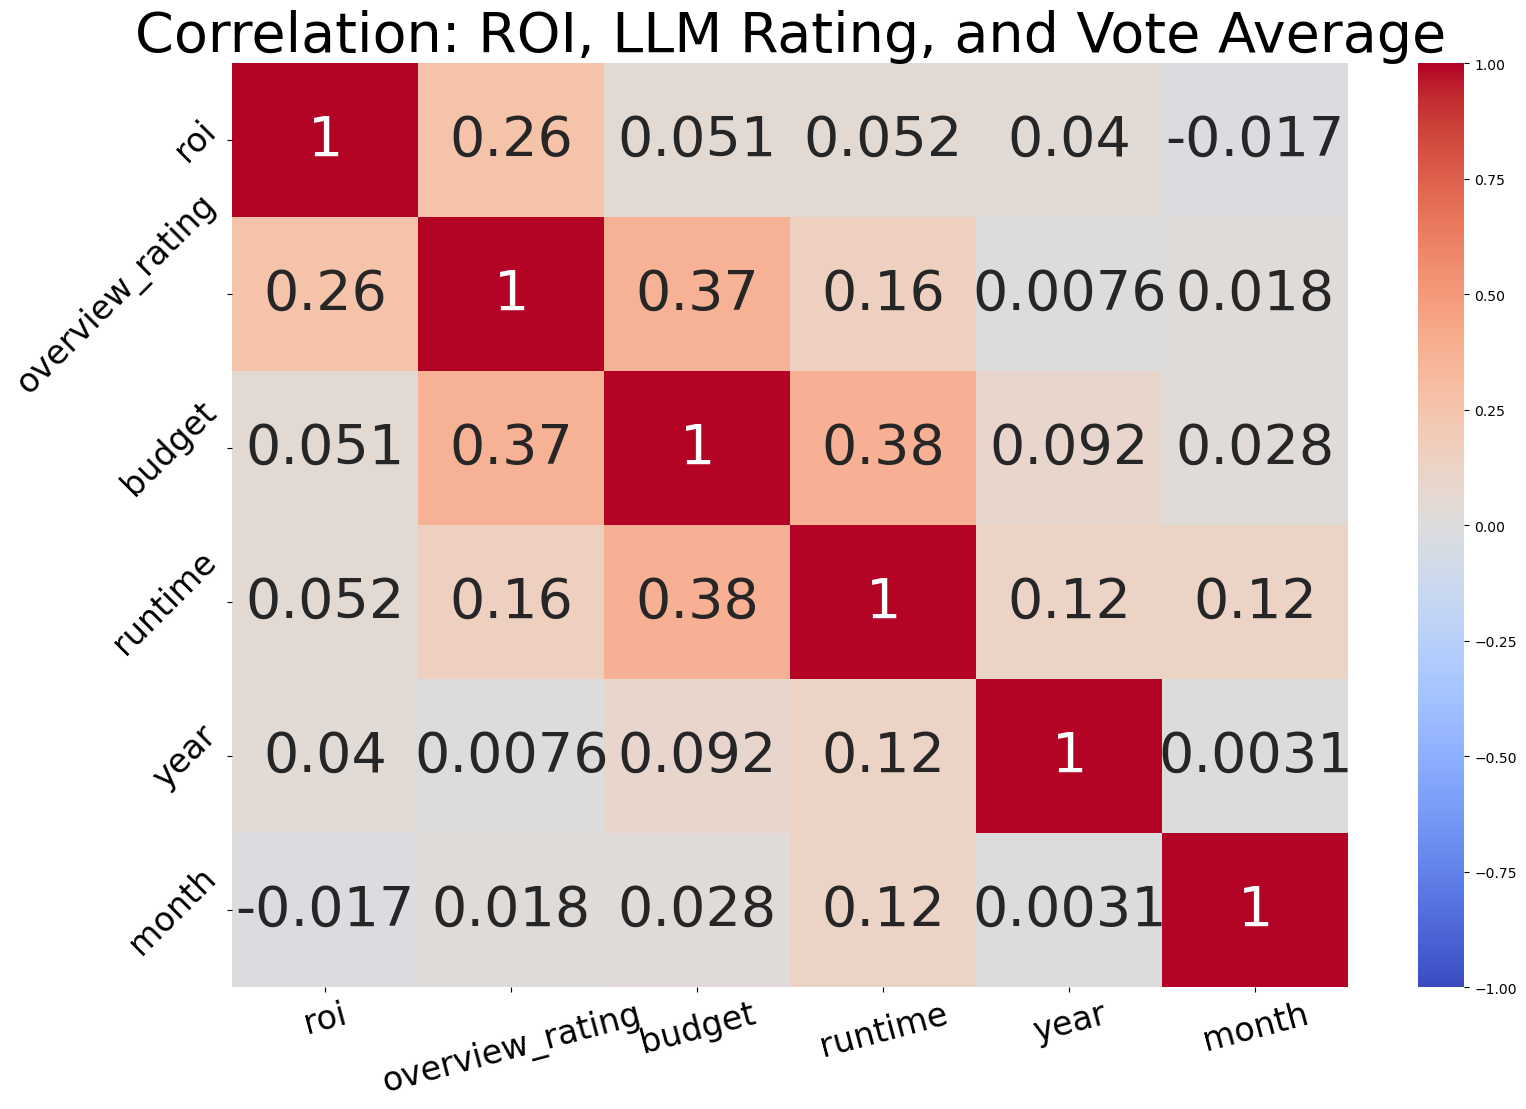

In [11]:
import seaborn as sns

df = df[df["budget"] > 1000]
df = df[df["revenue"] > 1000]
df = df[df["runtime"] > 40]

df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
df = df.dropna(subset=["release_date"])

df["roi"] = (df["revenue"] / df["budget"]).clip(upper=10)
df["success"] = (df["roi"] > 2).astype(int)
df["roi_log"] = np.log1p(df["roi"])
df["year"] = df["release_date"].dt.year
df["month"] = df["release_date"].dt.month

correlation_matrix = df[["roi", "vote_average", "overview_rating"]].corr()
print(correlation_matrix)

correlation_matrix = df[
    ["roi", "overview_rating", "budget", "runtime", "year", "month"]
].corr()
print(correlation_matrix)

plt.figure(figsize=(18, 12))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    annot_kws={"size": 40},
)
plt.title("Correlation: ROI, LLM Rating, and Vote Average", fontsize=40)
plt.xticks(fontsize=24, rotation=15)
plt.yticks(fontsize=24, rotation=45)
plt.savefig(
    "../results/correlation_matrix_heatmap.png"
)  # Save the figure as a PNG file
plt.show()
